<a href="https://colab.research.google.com/github/PJJT06/Challenge_TelecomX_1/blob/main/Challenge_TelecomX_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EXTRACCIÓN** 📌

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_json("TelecomX_Data.json")

In [3]:
data

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [17]:
data.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

# **TRANSFORMACIÓN ⚡**

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [27]:
from pandas import json_normalize

json_normalize(data["customer"])

,gender,SeniorCitizen,Partner,Dependents,tenure
0,Female,0,Yes,Yes,9
1,Male,0,No,No,9
2,Male,0,No,No,4
3,Male,1,Yes,No,13
4,Female,1,Yes,No,3
...,...,...,...,...,...
7262,Female,0,No,No,13
7263,Male,0,Yes,No,22
7264,Male,0,No,No,2
7265,Male,0,Yes,Yes,67


In [61]:
json_normalize(data["customer"]).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   gender         7267 non-null   object
 1   SeniorCitizen  7267 non-null   int64 
 2   Partner        7267 non-null   object
 3   Dependents     7267 non-null   object
 4   tenure         7267 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 284.0+ KB


In [34]:
#Normalizamos cada columna anidada de nuestro df inicial

customer_df = pd.json_normalize(data['customer'])
phone_df = pd.json_normalize(data['phone'])
internet_df = pd.json_normalize(data['internet'])
account_df = pd.json_normalize(data['account'])

account_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Contract          7267 non-null   object 
 1   PaperlessBilling  7267 non-null   object 
 2   PaymentMethod     7267 non-null   object 
 3   Charges.Monthly   7267 non-null   float64
 4   Charges.Total     7267 non-null   object 
dtypes: float64(1), object(4)
memory usage: 284.0+ KB


In [39]:
df_final = pd.concat([data[['customerID', 'Churn']], customer_df, phone_df, internet_df, account_df], axis=1)
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [41]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [42]:
df_final["Cuentas_Diarias"] = df_final["Charges.Monthly"] / 30

In [43]:
df_final

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.9,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [44]:
df_final.describe()

<bound method NDFrame.describe of       customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0     0002-ORFBO    No  Female              0     Yes        Yes       9   
1     0003-MKNFE    No    Male              0      No         No       9   
2     0004-TLHLJ   Yes    Male              0      No         No       4   
3     0011-IGKFF   Yes    Male              1     Yes         No      13   
4     0013-EXCHZ   Yes  Female              1     Yes         No       3   
...          ...   ...     ...            ...     ...        ...     ...   
7262  9987-LUTYD    No  Female              0      No         No      13   
7263  9992-RRAMN   Yes    Male              0     Yes         No      22   
7264  9992-UJOEL    No    Male              0      No         No       2   
7265  9993-LHIEB    No    Male              0     Yes        Yes      67   
7266  9995-HOTOH    No    Male              0     Yes        Yes      63   

     PhoneService     MultipleLines InternetService  ... DeviceProtection  \
0             Yes                No             DSL  ...               No   
1             Yes               Yes             DSL  ...               No   
2             Yes                No     Fiber optic  ...              Yes   
3             Yes                No     Fiber optic  ...              Yes   
4             Yes                No     Fiber optic  ...               No   
...           ...               ...             ...  ...              ...   
7262          Yes                No             DSL  ...               No   
7263          Yes               Yes     Fiber optic  ...               No   
7264          Yes                No             DSL  ...               No   
7265          Yes                No             DSL  ...              Yes   
7266           No  No phone service             DSL  ...              Yes   

     TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0            Yes         Yes              No        One year              Yes   
1             No          No             Yes  Month-to-month               No   
2             No          No              No  Month-to-month              Yes   
3             No         Yes             Yes  Month-to-month              Yes   
4            Yes         Yes              No  Month-to-month              Yes   
...          ...         ...             ...             ...              ...   
7262         Yes          No              No        One year               No   
7263          No          No             Yes  Month-to-month              Yes   
7264          No          No              No  Month-to-month              Yes   
7265         Yes          No             Yes        Two year               No   
7266          No         Yes             Yes        Two year               No   

         PaymentMethod Charges.Monthly Charges.Total  Cuentas_Diarias  
0         Mailed check           65.60         593.3         2.186667  
1         Mailed check           59.90         542.4         1.996667  
2     Electronic check           73.90        280.85         2.463333  
3     Electronic check           98.00       1237.85         3.266667  
4         Mailed check           83.90         267.4         2.796667  
...                ...             ...           ...              ...  
7262      Mailed check           55.15         742.9         1.838333  
7263  Electronic check           85.10        1873.7         2.836667  
7264      Mailed check           50.30         92.75         1.676667  
7265      Mailed check           67.85       4627.65         2.261667  
7266  Electronic check           59.00        3707.6         1.966667  

[7267 rows x 22 columns]>

# **CARGA Y ANALISIS 📊**

En esta parte me voy a centrar en encontrar una relacion del "chunt" con la cantidad de meses de contrato que tiene o tenía el usuario. En el camino me doy cuenta que hay usuarios que no aparecen si activos ni tampoco inactivos en el df por lo que preferi eliminarlos para evitar que nuestros datos se vean comprometidos por sus datos inciertos.


In [47]:
pd.crosstab(df_final["Churn"], df_final["Contract"])

Contract,Month-to-month,One year,Two year
Churn,,,
,130,46,48
No,2220,1307,1647
Yes,1655,166,48


In [56]:
df_final["Churn"].isin(["",' ']).value_counts()

,count
Churn,
False,7043
True,224


In [57]:
df_vacios = df_final[df_final["Churn"].isin(["",' '])]
df_vacios

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
30,0047-ZHDTW,,Female,0,No,No,11,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.00,929.3,2.633333
75,0120-YZLQA,,Male,0,No,No,71,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1355.1,0.663333
96,0154-QYHJU,,Male,0,No,No,29,Yes,No,DSL,...,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.2,1.958333
98,0162-RZGMZ,,Female,1,No,No,5,Yes,No,DSL,...,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85,1.996667
175,0274-VVQOQ,,Male,1,Yes,No,65,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45,3.438333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,,Female,0,No,No,14,Yes,Yes,DSL,...,No,No,No,No,One year,Yes,Mailed check,54.25,773.2,1.808333
7180,9872-RZQQB,,Female,0,Yes,No,49,No,No phone service,DSL,...,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75,1.355000
7211,9920-GNDMB,,Male,0,No,No,9,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,76.25,684.85,2.541667
7239,9955-RVWSC,,Female,0,Yes,Yes,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.9,0.641667


In [58]:
df_final = df_final[~df_final["Churn"].isin(["",' '])]

df_final


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.9,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [59]:
pd.crosstab(df_final["Churn"], df_final["Contract"])


Contract,Month-to-month,One year,Two year
Churn,,,
No,2220,1307,1647
Yes,1655,166,48


In [63]:
df_final.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


In [64]:
df_final.groupby("Churn")["tenure"].median()

,tenure
Churn,
No,38.0
Yes,10.0


##Fuga Temprana Crítica: Mientras que el promedio era de 18 meses, la mediana de 10 nos dice que el 50% de los clientes que abandonan lo hacen antes de cumplir el primer año. El promedio de 18 estaba inflado por unos pocos clientes antiguos que se fueron, pero la realidad es que la 'hemorragia' de clientes es inmediata.

#Falla en la Experiencia Inicial: Los clientes no se van porque se cansen del servicio tras años de uso; se van porque algo falla en los primeros meses (mala instalación, primera factura confusa o fin de una promoción inicial).

#Decisión de Negocio: La estrategia de retención no debe esperar a los 18 meses. Las acciones preventivas deben ocurrir antes del mes 6, que es donde parece estar el mayor riesgo de deserción.

In [74]:

sns.set_style('whitegrid')
sns.set_context('talk')

# Paleta de colores personalizada en español
paleta_personalizada = {'No': '#3498db', 'Yes': '#e74c3c'}
sns.set_palette(list(paleta_personalizada.values()))

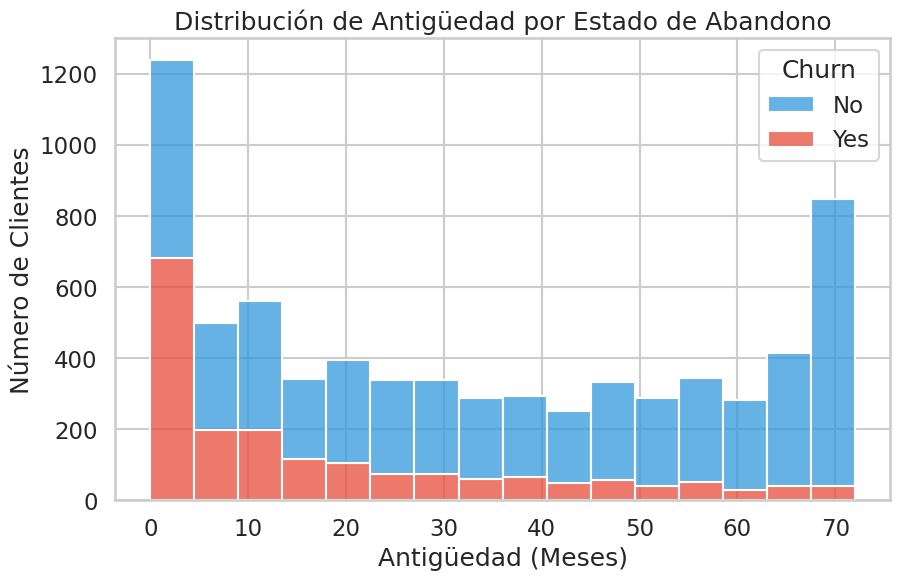

In [75]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_final, x='tenure', hue='Churn', multiple='stack', palette=paleta_personalizada)
plt.title('Distribución de Antigüedad por Estado de Abandono')
plt.xlabel('Antigüedad (Meses)')
plt.ylabel('Número de Clientes')
plt.show()

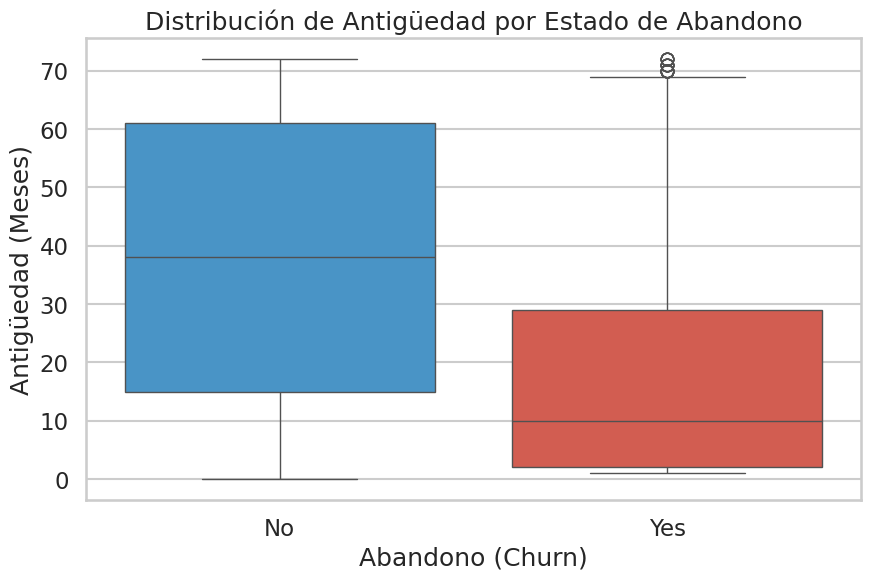

In [76]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x="Churn", y="tenure", hue="Churn", palette=paleta_personalizada, legend=False)
plt.title("Distribución de Antigüedad por Estado de Abandono")
plt.xlabel("Abandono (Churn)")
plt.ylabel("Antigüedad (Meses)")
plt.show()

In [77]:
df_abandonos = df_final[df_final['Churn'] == 'Yes']
total_abandonos = len(df_abandonos)
abandonos_tempranos = len(df_abandonos[df_abandonos['tenure'] <= 12])
porcentaje_temprano = (abandonos_tempranos / total_abandonos) * 100
mediana_antiguedad_abandono = df_abandonos['tenure'].median()

print(f'Total de clientes que abandonaron: {total_abandonos}')
print(f'Clientes que se fueron en los primeros 12 meses: {abandonos_tempranos}')
print(f'Porcentaje de fuga en el primer año: {porcentaje_temprano:.2f}%')
print(f'Mediana de antigüedad de los que se van: {mediana_antiguedad_abandono} meses')

Total de clientes que abandonaron: 1869
Clientes que se fueron en los primeros 12 meses: 1037
Porcentaje de fuga en el primer año: 55.48%
Mediana de antigüedad de los que se van: 10.0 meses


## Los resultados obtenidos nos hacen pensar que algo esta pasando en los primeros meses para que los usuarios abandonen o se quede, continuaremos comparando mas datos para una respuesta mas certera

In [80]:
df_primer_ano = df_final[df_final['tenure'] <= 12]
df_primer_ano

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4,2.796667
5,0013-MHZWF,No,Female,0,No,Yes,9,Yes,No,DSL,...,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),69.40,571.45,2.313333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7257,9975-SKRNR,No,Male,0,No,No,1,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,18.90,18.9,0.630000
7259,9979-RGMZT,No,Female,0,No,No,7,Yes,No,Fiber optic,...,No,No,Yes,Yes,One year,Yes,Mailed check,94.05,633.45,3.135000
7260,9985-MWVIX,Yes,Female,0,No,No,1,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,2.338333
7261,9986-BONCE,Yes,Female,0,No,No,4,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.95,85.5,0.698333


In [83]:
df_primer_ano.groupby("Churn")["Charges.Monthly"].mean()

,Charges.Monthly
Churn,
No,46.714970
Yes,66.493973


In [84]:
df_primer_ano.groupby("Churn")["Charges.Monthly"].median()

,Charges.Monthly
Churn,
No,45.40
Yes,73.85


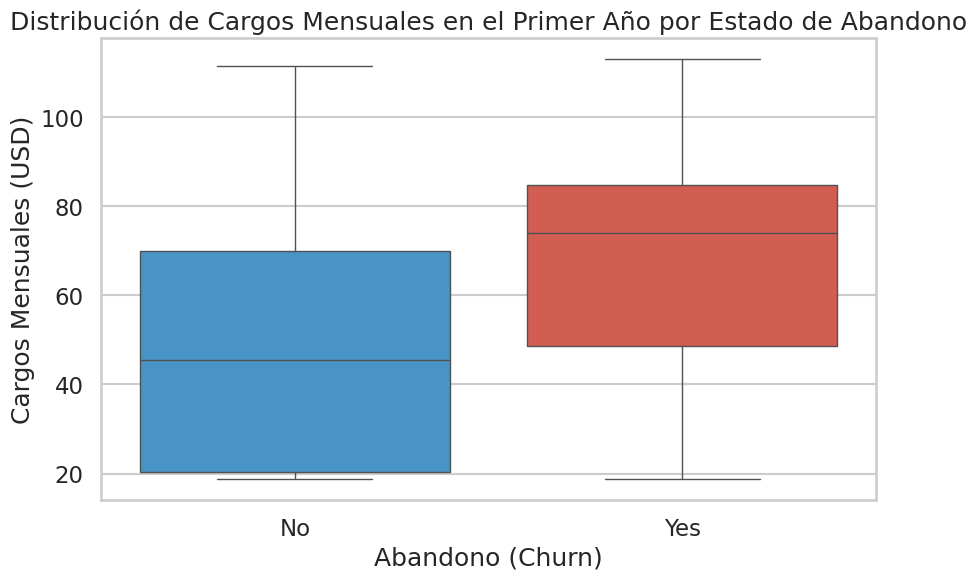

In [86]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_primer_ano, x='Churn', y='Charges.Monthly', hue='Churn', palette=paleta_personalizada, legend=False)
plt.title('Distribución de Cargos Mensuales en el Primer Año por Estado de Abandono')
plt.xlabel('Abandono (Churn)')
plt.ylabel('Cargos Mensuales (USD)')
plt.show()

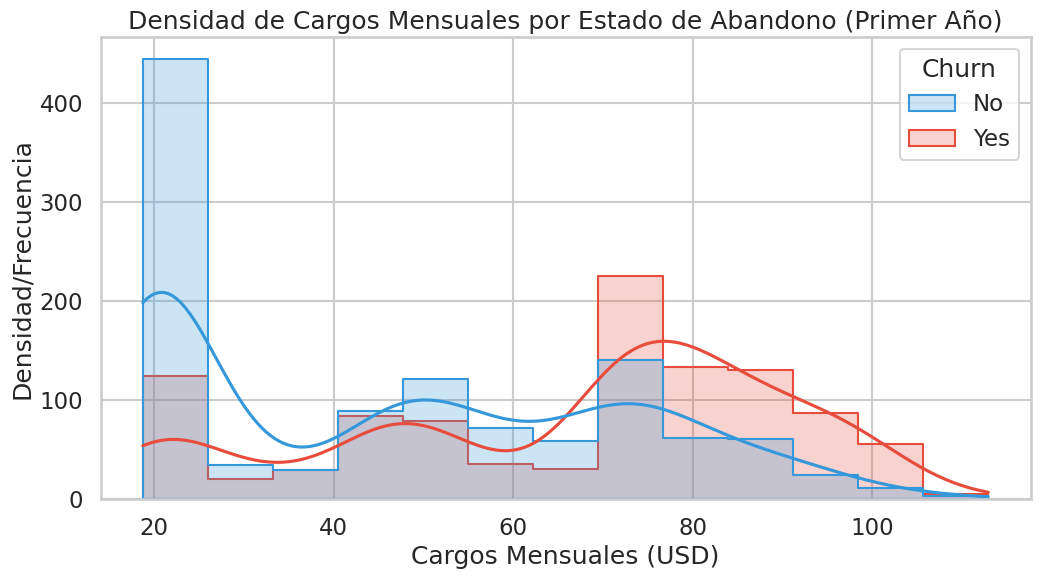

In [88]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_primer_ano, x='Charges.Monthly', hue='Churn', kde=True, palette=paleta_personalizada, element='step')
plt.title('Densidad de Cargos Mensuales por Estado de Abandono (Primer Año)')
plt.xlabel('Cargos Mensuales (USD)')
plt.ylabel('Densidad/Frecuencia')
plt.show()

# Informe Final de Análisis de Fuga (Churn) - TelecomX

### Introducción
El presente análisis tiene como objetivo principal identificar los factores que impulsan la pérdida de clientes (**Churn**) en la compañía, utilizando para ello el conjunto de datos `TelecomX_Data.json`.

A través de este estudio, se busca transformar los datos crudos en información estratégica que permita comprender por qué los usuarios deciden abandonar el servicio. El fin último es proporcionar hallazgos basados en datos que sirvan de guía para que la organización desarrolle e implemente estrategias de retención de clientes más efectivas y personalizadas.

Resumen de Limpieza y Procesamiento
En esta etapa se realizaron varias acciones clave para preparar los datos para el análisis:

Normalización de JSON: El conjunto de datos inicial contenía estructuras anidadas en las columnas customer, phone, internet y account. Se utilizó la función json_normalize para aplanar estos objetos y convertir los atributos en columnas individuales, facilitando así el análisis tabular.
Cálculo de Cuentas Diarias: Se creó la nueva columna Cuentas_Diarias dividiendo los cargos mensuales (Charges.Monthly) por 30. Esto permite entender el costo operativo diario por cada usuario.
Depuración de Datos: Se identificaron y eliminaron 224 registros que presentaban valores vacíos (strings vacíos) en la columna Churn. Esta limpieza fue fundamental para asegurar la integridad de los resultados y evitar sesgos causados por datos inciertos sobre el estado de abandono de los clientes.

Síntesis del Análisis Exploratorio
El análisis de los datos ha revelado hallazgos críticos sobre el comportamiento de abandono (churn) de los clientes:

Fuga Temprana Crítica: Existe una diferencia significativa entre el promedio y la mediana de antigüedad de los clientes que abandonan. Mientras que el promedio de permanencia antes de la deserción es de 18 meses, la mediana es de solo 10 meses. Esto indica que el 50% de los clientes que se van lo hacen antes de cumplir su primer año, lo que sugiere una 'hemorragia' inmediata de usuarios.

Impacto del Tipo de Contrato: El análisis por tipo de contrato muestra que los contratos 'Month-to-month' (mes a mes) presentan el riesgo más alto. La gran mayoría de las deserciones se concentran en esta modalidad en comparación con los contratos de uno o dos años, que muestran una retención mucho más sólida.

Conclusión sobre la Experiencia Inicial: El riesgo de deserción no es un fenómeno que ocurra tras años de servicio por cansancio del producto. Por el contrario, es un riesgo inmediato que sugiere fallas en la experiencia inicial del cliente, como problemas en la instalación, la primera facturación o el fin de promociones de bienvenida.

Recomendación de Negocio: Las estrategias de retención deben enfocarse en los primeros 6 a 10 meses de vida del cliente para mitigar la deserción temprana.

Hallazgos de Sensibilidad al Precio
Análisis de Cargos Mensuales y Deserción Temprana
Tras analizar los datos financieros del primer año de los clientes, se han identificado patrones críticos de sensibilidad al precio:

Brecha de Costos: Existe una diferencia significativa en lo que pagan los usuarios. Durante su primer año, los clientes que permanecen con la compañía (No Churn) tienen un cargo mensual mediano de aproximadamente 45 USD. En contraste, aquellos que abandonan el servicio (Yes Churn) presentan una mediana de cargos de 73.85 USD.
Umbral de Riesgo de 70 USD: Se observa que el riesgo de abandono se incrementa drásticamente una vez que los cargos mensuales superan la barrera de los 70 USD. Este punto parece ser el límite de tolerancia para la mayoría de los nuevos suscriptores.
Factor de Deserción: Esta marcada sensibilidad al precio es uno de los motores principales de la 'fuga temprana'. Los altos costos iniciales, posiblemente derivados de la falta de descuentos o la selección de paquetes premium desde el inicio, generan una desconexión entre el valor percibido y el costo, impulsando al cliente a cancelar el servicio en sus primeros meses.

## Conclusiones y Recomendaciones Clave

Basado en el análisis de deserción (churn) realizado para TelecomX, se proponen las siguientes estrategias:

### 1. Sistema de Alertas de Retención Temprana
* **Acción:** Implementar alertas automáticas para clientes cuyos cargos mensuales superen los **70 USD**.
* **Justificación:** Los datos muestran que los clientes que abandonan en el primer año tienen una mediana de cargos mensuales (73.85 USD) significativamente mayor que los que permanecen (45.40 USD).

### 2. Revisión de la Experiencia Inicial (Meses 6-10)
* **Acción:** Auditar los puntos de contacto con el cliente y las ofertas promocionales entre el mes 6 y el mes 10.
* **Justificación:** La mediana de antigüedad de los clientes que se van es de solo 10 meses, lo que sugiere que el fin de las promociones iniciales o fallos en el servicio temprano son críticos.

### 3. Incentivos para Contratos a Largo Plazo
* **Acción:** Lanzar campañas para migrar a los clientes de contratos 'Month-to-month' hacia compromisos de 'One year' o 'Two year'.
* **Justificación:** El análisis de contingencia muestra una tasa de abandono drásticamente menor en contratos de largo plazo comparado con los mensuales.

### 4. Estabilización de Cargos
* **Acción:** Evaluar la competitividad de los precios para servicios de alto valor (como Fiber Optic) para evitar que el alto costo sea el principal motor de fuga en el primer año.